# Leuven Bike Road Dataset — Inference Features

Builds a dataset matching `sites_enriched_clean.csv` schema for all bike-accessible
road segments within the administrative boundary of Leuven.

**Output:** `explo/andy/output/leuven_bike_roads.csv`

---
### Why we filter short segments
OSMnx splits every road at each junction, producing many tiny edge stubs
(median length ~40 m, 57% of edges < 50 m). Adjacent short stubs share the same
road type, POI neighbourhood, and population, so keeping them only adds computation
with no new predictive information.

| `MIN_LENGTH_M` | Segments kept | Reduction |
|---|---|---|
| 0 (no filter) | ~7,700 | -- |
| **50 m** | **~3,300** | **~57%** |
| 100 m | ~1,800 | ~76% |

All major cycling routes are still fully covered.

## 1  Imports & Settings

In [ ]:
import os, time, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
from shapely.geometry import Point
warnings.filterwarnings('ignore')
ox.settings.log_console = False

OUTPUT_DIR  = 'output'
CACHE_DIR   = 'output/leuven_cache'
OUTPUT_PATH = f'{OUTPUT_DIR}/leuven_bike_roads.csv'
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Key reduction parameter ───────────────────────────────────────────────────
# Segments shorter than this are dropped (tiny OSM junction stubs).
# 50 m keeps ~3,300 segments (57% reduction) while covering all cycle paths.
# 100 m keeps ~1,800 segments (76% reduction) — use if still too slow.
MIN_LENGTH_M = 200

POI_RADII = [250, 500, 1000]
POI_TAGS  = {
    'shop'      : {'shop': True},
    'education' : {'amenity': ['school', 'university', 'college', 'kindergarten']},
    'hotel'     : {'tourism': ['hotel', 'hostel', 'motel', 'guest_house']},
    'hospital'  : {'amenity': ['hospital', 'clinic', 'doctors', 'pharmacy']},
}

# ── Feature mappings: OSM highway type -> training data vocabulary ─────────────
HIGHWAY_TO_MORPHOLOGY = {
    'cycleway'      : 'cycleway_footpath',
    'footway'       : 'cycleway_footpath',
    'path'          : 'cycleway_footpath',
    'track'         : 'cycleway_footpath',
    'pedestrian'    : 'cycleway_footpath',
    'bridleway'     : 'cycleway_footpath',
    'residential'   : 'single_carriageway',
    'living_street' : 'single_carriageway',
    'unclassified'  : 'single_carriageway',
    'tertiary'      : 'single_carriageway',
    'tertiary_link' : 'single_carriageway',
    'secondary'     : 'divided_road_non_motorway',
    'secondary_link': 'divided_road_non_motorway',
    'primary'       : 'divided_road_non_motorway',
    'primary_link'  : 'divided_road_non_motorway',
    'trunk'         : 'divided_road_non_motorway',
    'service'       : 'service_road',
}
HIGHWAY_TO_CAT_CODE = {
    'cycleway'      : '-9',  'footway'       : '-9',
    'path'          : '-9',  'track'         : '-9',
    'pedestrian'    : '-9',  'bridleway'     : '-9',
    'living_street' : 'EW',  'service'       : 'EW',  'residential'   : 'EW',
    'unclassified'  : 'IW',  'tertiary'      : 'IW',  'tertiary_link' : 'IW',
    'secondary'     : 'OW',  'secondary_link': 'OW',
    'primary'       : 'RW',  'primary_link'  : 'RW',
    'trunk'         : 'VHW',
}
CAT_CODE_TO_EN = {
    'EW': 'local_access_road', 'IW': 'local_road',
    'OW': 'minor_road',        'RW': 'regional_road',
    'VHW': 'high_capacity_road', '-9': 'not_applicable',
}
print('Settings loaded.')

Settings loaded.


## 2  Fetch Leuven Boundary & Bike Road Network

In [2]:
GRAPH_CACHE = f'{CACHE_DIR}/leuven_bike_graph.graphml'

if os.path.exists(GRAPH_CACHE):
    G = ox.load_graphml(GRAPH_CACHE)
    print(f'Loaded bike network from cache.')
else:
    print('Fetching Leuven bike road network from OSM...')
    t0 = time.time()
    G = ox.graph_from_place('Leuven, Belgium', network_type='bike', retain_all=False)
    ox.save_graphml(G, GRAPH_CACHE)
    print(f'Done in {time.time()-t0:.1f} s -- cached.')

print(f'Nodes: {len(G.nodes):,}   Edges (segments): {len(G.edges):,}')

Loaded bike network from cache.
Nodes: 8,580   Edges (segments): 20,662


## 3  Convert Graph Edges to GeoDataFrame  +  Length Filter

In [3]:
# Get edges (road segments) as GeoDataFrame
edges = ox.graph_to_gdfs(G, nodes=False).reset_index()
print(f'Raw OSM segments  : {len(edges):,}')
print(f'CRS               : {edges.crs}')

# Compute segment midpoint (centroid) in WGS84
edges['longitude'] = edges.geometry.centroid.x
edges['latitude']  = edges.geometry.centroid.y

# Compute segment length in metres (project to Lambert 72)
edges_lam_tmp = edges.to_crs('EPSG:31370')
edges['length_m'] = edges_lam_tmp.geometry.length.round(2)

# ── Length filter: drop tiny OSM junction stubs ───────────────────────────────
before = len(edges)
edges = edges[edges['length_m'] >= MIN_LENGTH_M].copy().reset_index(drop=True)
reduction_pct = 100 * (before - len(edges)) / before
print(f'After length >= {MIN_LENGTH_M} m: {len(edges):,}  (dropped {before - len(edges):,} short stubs, {reduction_pct:.1f}% reduction)')

# Normalise highway type (OSM sometimes stores as list)
edges['highway_type'] = edges['highway'].apply(
    lambda h: h[0] if isinstance(h, list) else h
)

print('\nhighway_type distribution:')
print(edges['highway_type'].value_counts().head(15))

Raw OSM segments  : 20,662
CRS               : epsg:4326
After length >= 50 m: 8,492  (dropped 12,170 short stubs, 58.9% reduction)

highway_type distribution:
highway_type
residential      2140
service          1236
cycleway         1170
path             1146
track             852
tertiary          570
living_street     424
unclassified      397
primary           269
pedestrian        199
secondary          79
primary_link        7
trunk               2
trunk_link          1
Name: count, dtype: int64


## 4  Map OSM Attributes -> Training Schema Features

In [4]:
# ── Road name ──────────────────────────────────────────────────────────────────
edges['road_name'] = edges.get('name', pd.Series('Unknown', index=edges.index))
edges['road_name'] = edges['road_name'].apply(
    lambda x: x[0] if isinstance(x, list) else x
).fillna('Unknown')

# ── Morphology & road category ────────────────────────────────────────────────
edges['morphology_en']       = edges['highway_type'].map(HIGHWAY_TO_MORPHOLOGY).fillna('single_carriageway')
edges['road_category_code']  = edges['highway_type'].map(HIGHWAY_TO_CAT_CODE).fillna('IW')
edges['road_category_en']    = edges['road_category_code'].map(CAT_CODE_TO_EN)

# ── Bike lane width ───────────────────────────────────────────────────────────
WIDTH_TAGS = ['cycleway:width', 'cycleway:right:width', 'cycleway:left:width',
              'cycleway:both:width', 'width']

def _parse_width(val):
    """Parse a width string/number to float metres. Returns NaN on failure."""
    if pd.isna(val):
        return np.nan
    s = str(val).lower().strip()
    if s.endswith('cm'):
        try: return float(s.replace('cm', '').strip()) / 100
        except: pass
    for u in [' meters', ' meter', ' m', 'm']:
        s = s.replace(u, '').strip()
    try: return float(s)
    except: return np.nan

def get_width_from_row(row):
    """
    Extract bike-lane width from OSM tags.
    FIX: OSMnx sometimes stores tag values as lists (multi-value tags).
    We always extract a scalar before calling pd.isna() to avoid
    'ValueError: truth value of an array is ambiguous'.
    """
    for tag in WIDTH_TAGS:
        if tag not in row.index:
            continue
        val = row[tag]
        # OSMnx may return a list for multi-value tags -- take the first element
        if isinstance(val, (list, np.ndarray)):
            val = val[0] if len(val) > 0 else np.nan
        # Now val is a scalar -- safe to check NaN
        if pd.isna(val):
            continue
        w = _parse_width(val)
        if not np.isnan(w) and 0 < w < 20:
            return w
    return np.nan

edges['bike_lane_width_m'] = edges.apply(get_width_from_row, axis=1)

# Impute missing with median per morphology type
overall_med = edges['bike_lane_width_m'].median()
edges['bike_lane_width_m'] = edges.groupby('morphology_en')['bike_lane_width_m'].transform(
    lambda x: x.fillna(x.median() if not np.isnan(x.median()) else overall_med)
)
edges['bike_width_imputed'] = edges['bike_lane_width_m'].isna()
edges['bike_lane_width_m']  = edges['bike_lane_width_m'].fillna(overall_med)

# ── Other static features ──────────────────────────────────────────────────────
edges['has_cycleway']       = True
edges['bike_lane_source']   = 'osm_bike_network'
edges['access_en']          = 'public_road'
edges['geometry_method_en'] = 'surveyed'
edges['municipality']       = 'Leuven'
edges['district_code']      = 'AWV214'
edges['road_code']          = edges['osmid'].astype(str)
edges['operator']           = 'Unknown'
edges['interval_min']       = 60
edges['install_date']       = pd.NaT
edges['sensor_age_days']    = 0
edges['install_year']       = pd.Timestamp.today().year
edges['manager_code']       = '24062'
edges['manager_label']      = 'Stad Leuven'
edges['dist_to_segment_m']  = 0.0
edges['segment_id']         = edges['osmid']
edges['site_id']            = edges['osmid']
edges['site_name']          = edges['road_name']

print(f'Features mapped. bike_lane_width_m imputed: {edges["bike_width_imputed"].sum()} segments')
print('\nMorphology distribution:')
print(edges['morphology_en'].value_counts())

Features mapped. bike_lane_width_m imputed: 0 segments

Morphology distribution:
morphology_en
single_carriageway           3532
cycleway_footpath            3367
service_road                 1236
divided_road_non_motorway     357
Name: count, dtype: int64


## 5  POI Counts  (vectorized spatial join + multi-server fallback)

**Fix for ConnectTimeout**: The Overpass API can be unreachable on some networks
(VPN, university firewall). This cell now:
1. Sets a **5-minute timeout** instead of the default short one
2. **Keeps `use_cache = True`** so previous downloads are reused immediately
3. **Tries 3 different Overpass mirror servers** if the first one times out
4. Once downloaded, saves `.gpkg` files locally so subsequent runs are instant

**POI counting**: vectorized `geopandas.sjoin` instead of a Python loop (10-50x faster).

In [5]:
# Project segment centroids to Lambert 72 for accurate metre-based buffers
edges_lam = gpd.GeoDataFrame(
    edges[['segment_id']].copy(),
    geometry=gpd.GeoSeries(
        [Point(lon, lat) for lon, lat in zip(edges['longitude'], edges['latitude'])],
        crs='EPSG:4326'
    ),
    index=edges.index
).to_crs('EPSG:31370')

# Leuven bounding box (north, south, east, west)
# 1. FIXED: Bounding Box is now (West, South, East, North)
LEUVEN_BBOX = (4.62, 50.83, 4.73, 50.92)

# ── Connection settings ────────────────────────────────────────────────────────
ox.settings.timeout    = 300   # 5-minute timeout (default is too short)
ox.settings.use_cache  = True  # reuse previously downloaded HTTP responses

# Multiple Overpass endpoints -- tries each in order until one succeeds
OVERPASS_ENDPOINTS = [
    'https://overpass-api.de/api/interpreter',           # main server
    'https://overpass.kumi.systems/api/interpreter',     # mirror 1
    'https://maps.mail.ru/osm/tools/overpass/api/interpreter',  # mirror 2
]

poi_gdfs = {}
print('Downloading POI data for Leuven (cached to disk after first download)...')

for cat, tags in POI_TAGS.items():
    cache_path = f'{CACHE_DIR}/poi_{cat}.gpkg'

    # ── Use .gpkg cache if it already exists ──────────────────────────────────
    if os.path.exists(cache_path):
        poi_gdfs[cat] = gpd.read_file(cache_path)
        print(f'  {cat:12s}: {len(poi_gdfs[cat]):,} features from local cache')
        continue

    # ── Try each Overpass endpoint until one works ─────────────────────────────
    gdf = None
    for endpoint in OVERPASS_ENDPOINTS:
        try:
            ox.settings.overpass_url = endpoint
            t0 = time.time()
            print(f'  {cat:12s}: trying {endpoint} ...')
            gdf = ox.features_from_bbox(bbox=LEUVEN_BBOX, tags=tags)
            gdf = gdf.copy()
            gdf['geometry'] = gdf.geometry.centroid
            gdf = gdf.to_crs('EPSG:31370')
            gdf[['geometry']].to_file(cache_path, driver='GPKG')  # save for next run
            poi_gdfs[cat] = gdf
            print(f'  {cat:12s}: {len(gdf):,} features downloaded in {time.time()-t0:.1f}s -- saved to cache')
            break  # success -- stop trying other endpoints
        except Exception as e:
            print(f'  {cat:12s}: FAILED ({type(e).__name__}: {e}) -- trying next server...')

    if cat not in poi_gdfs or poi_gdfs[cat] is None:
        print(f'  {cat:12s}: ALL endpoints failed -- POI counts will be 0.')
        print(f'              TIP: Disable VPN, check your internet, then re-run this cell.')
        poi_gdfs[cat] = None

# ── Vectorized spatial join (replaces slow Python loop) ───────────────────────
print(f'\nCounting POIs per segment per radius (vectorized sjoin, {len(edges):,} segments)...')
t0 = time.time()

for cat, poi_gdf in poi_gdfs.items():
    for r in POI_RADII:
        col = f'poi_{cat}_{r}m'
        if poi_gdf is None or poi_gdf.empty:
            edges[col] = 0
            continue

        # Build buffer GeoDataFrame around each segment centroid
        buf_gdf = gpd.GeoDataFrame(
            {'seg_idx': edges_lam.index},
            geometry=edges_lam.geometry.buffer(r),
            crs='EPSG:31370'
        ).reset_index(drop=True)

        # Spatial join: which POIs fall inside each buffer?
        joined = gpd.sjoin(
            poi_gdf[['geometry']].reset_index(drop=True),
            buf_gdf,
            how='inner',
            predicate='within'
        )
        counts = joined.groupby('seg_idx').size()
        edges[col] = counts.reindex(edges.index).fillna(0).astype(int).values

print(f'Done in {time.time()-t0:.1f} s')
print('\nPOI summary (city total):')
for cat in POI_TAGS:
    col = f'poi_{cat}_1000m'
    if col in edges.columns:
        print(f'  {cat:12s}: total={edges[col].sum():,}  mean={edges[col].mean():.1f}/segment')

  shop        : trying https://overpass-api.de/api/interpreter ...
  shop        : FAILED (ConnectTimeout: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x1d09baac2d0>, 'Connection to overpass-api.de timed out. (connect timeout=180)'))) -- trying next server...
  shop        : trying https://overpass.kumi.systems/api/interpreter ...
  shop        : 989 features downloaded in 361.7s -- saved to cache
  education   : trying https://overpass-api.de/api/interpreter ...
  education   : 324 features downloaded in 71.2s -- saved to cache
  hotel       : trying https://overpass-api.de/api/interpreter ...
  hotel       : 45 features downloaded in 189.3s -- saved to cache
  hospital    : trying https://overpass-api.de/api/interpreter ...
  hospital    : 118 features downloaded in 61.5s -- saved to cache

Counting POIs per segment per radius (ve

## 6  Assemble Final Dataset -- Match Training Schema

In [6]:
TRAINING_COLS = [
    'site_id', 'site_name', 'longitude', 'latitude',
    'municipality', 'district_code', 'road_code', 'operator',
    'interval_min', 'install_date', 'segment_id', 'road_name',
    'morphology_en', 'road_category_code', 'road_category_en',
    'access_en', 'geometry_method_en', 'manager_code', 'manager_label',
    'length_m', 'dist_to_segment_m', 'bike_lane_width_m',
    'has_cycleway', 'bike_lane_source',
    'poi_shop_250m', 'poi_shop_500m', 'poi_shop_1000m',
    'poi_education_250m', 'poi_education_500m', 'poi_education_1000m',
    'poi_hotel_250m', 'poi_hotel_500m', 'poi_hotel_1000m',
    'poi_hospital_250m', 'poi_hospital_500m', 'poi_hospital_1000m',
    'sensor_age_days', 'install_year', 'bike_width_imputed',
]

leuven_df = edges[TRAINING_COLS].copy()

# Remove duplicate segments (parallel edges between same nodes)
leuven_df = leuven_df.drop_duplicates(subset='segment_id').reset_index(drop=True)

print(f'Final dataset: {leuven_df.shape[0]:,} segments x {leuven_df.shape[1]} columns')
print(f'Missing values: {leuven_df.isna().sum().sum()}')
print(f'Length range: {leuven_df.length_m.min():.0f}m - {leuven_df.length_m.max():.0f}m  (median {leuven_df.length_m.median():.0f}m)')
display(leuven_df.head(5))

Final dataset: 3,924 segments x 39 columns
Missing values: 3924
Length range: 50m - 2069m  (median 104m)


,site_id,site_name,longitude,latitude,municipality,district_code,road_code,operator,interval_min,install_date,...,poi_education_1000m,poi_hotel_250m,poi_hotel_500m,poi_hotel_1000m,poi_hospital_250m,poi_hospital_500m,poi_hospital_1000m,sensor_age_days,install_year,bike_width_imputed
0,3677823,Naamsevest,4.706967,50.869167,Leuven,AWV214,3677823,Unknown,60,NaT,...,163,1,1,8,3,7,19,0,2026,False
1,3358657,Elzasgang,4.698668,50.869596,Leuven,AWV214,3358657,Unknown,60,NaT,...,175,0,1,7,1,6,22,0,2026,False
2,"[1063831514, 8131717]",Tiensevest,4.715712,50.877481,Leuven,AWV214,"[1063831514, 8131717]",Unknown,60,NaT,...,70,0,6,18,0,7,31,0,2026,False
3,"[863272992, 863272993, 863272994, 8131717]",Tiensevest,4.714718,50.874743,Leuven,AWV214,"[863272992, 863272993, 863272994, 8131717]",Unknown,60,NaT,...,74,1,2,17,1,4,25,0,2026,False
4,3343962,Schepenenstraat,4.711071,50.873659,Leuven,AWV214,3343962,Unknown,60,NaT,...,126,2,2,17,0,6,28,0,2026,False


## 7  Validate Against Training Schema

Columns in training but missing in Leuven : None
Extra columns in Leuven not in training    : None


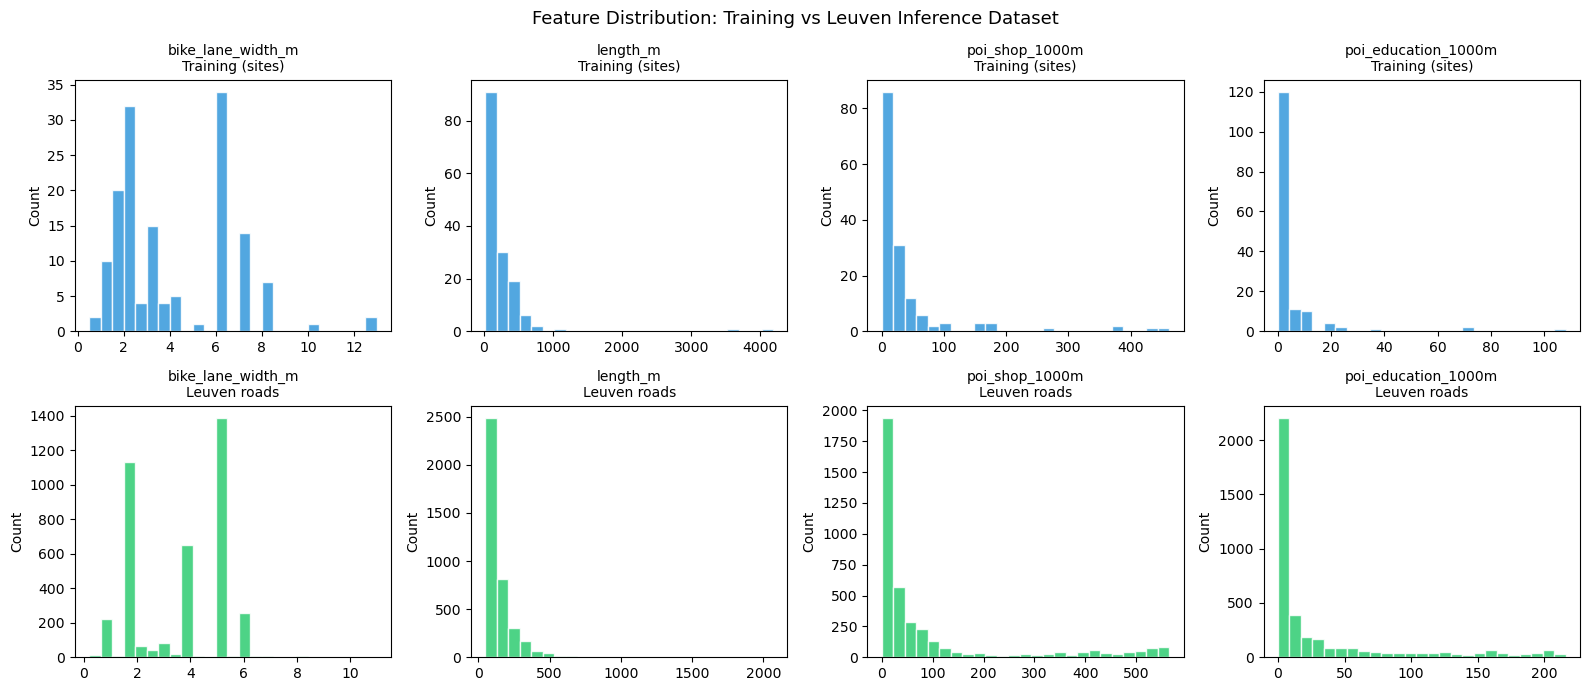

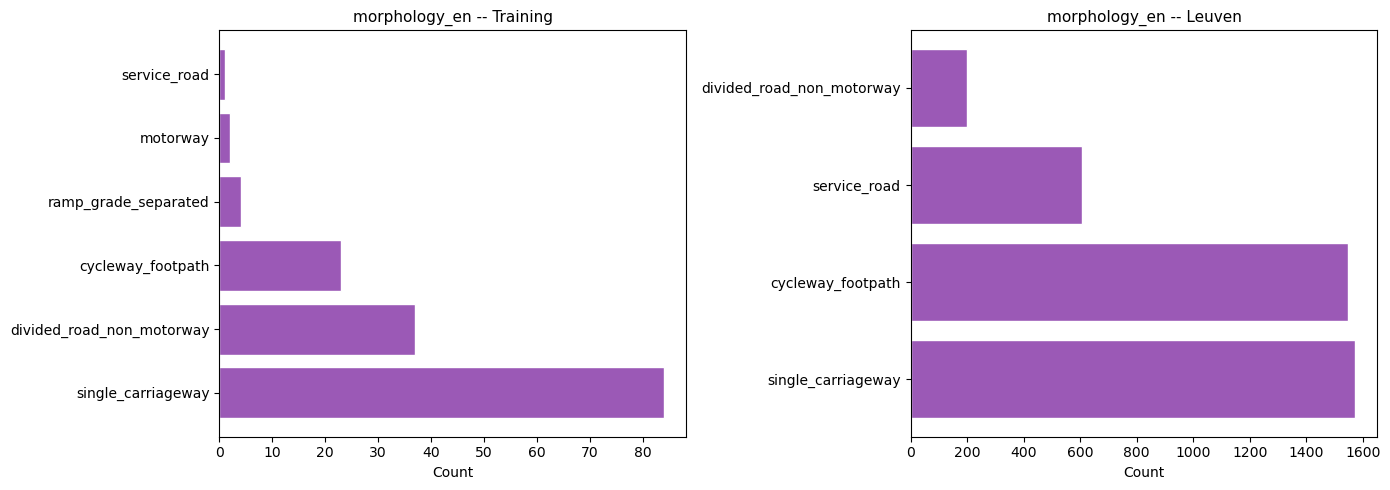

In [8]:
import matplotlib.pyplot as plt

train_df = pd.read_csv('output/sites_enriched_clean.csv')

# Column match check
missing_cols = set(train_df.columns) - set(leuven_df.columns)
extra_cols   = set(leuven_df.columns) - set(train_df.columns)
print('Columns in training but missing in Leuven :', missing_cols or 'None')
print('Extra columns in Leuven not in training    :', extra_cols   or 'None')

# Compare key numeric distributions
compare_cols = ['bike_lane_width_m', 'length_m',
                'poi_shop_1000m', 'poi_education_1000m']
fig, axes = plt.subplots(2, len(compare_cols), figsize=(16, 7), sharey=False)
for j, col in enumerate(compare_cols):
    for i, (label, data) in enumerate([('Training (sites)', train_df), ('Leuven roads', leuven_df)]):
        ax = axes[i][j]
        ax.hist(data[col].dropna(), bins=25, color=['#3498db','#2ecc71'][i],
                edgecolor='white', alpha=0.85)
        ax.set_title(f'{col}\n{label}', fontsize=10)
        ax.set_ylabel('Count')
plt.suptitle('Feature Distribution: Training vs Leuven Inference Dataset', fontsize=13)
plt.tight_layout()
plt.show()

# Morphology comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, data) in zip(axes, [('Training', train_df), ('Leuven', leuven_df)]):
    counts = data['morphology_en'].value_counts()
    ax.barh(counts.index, counts.values, color='#9b59b6', edgecolor='white')
    ax.set_title(f'morphology_en -- {label}', fontsize=11)
    ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## 8  Export

In [10]:
leuven_df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved: {OUTPUT_PATH}')
print(f'   {leuven_df.shape[0]:,} road segments x {leuven_df.shape[1]} columns')
print()
# display(pd.DataFrame({
#     'dtype'  : leuven_df.dtypes,
#     'missing': leuven_df.isna().sum(),
#     'unique' : leuven_df.nunique(),
# }))

Saved: explo/andy/output/leuven_bike_roads.csv
   3,924 road segments x 39 columns

